Knot vector: [0.    0.    0.    0.    0.333 0.667 1.    1.    1.    1.   ]

Clamping verification:
  curve(0) = 0.95000000
  c0.y     = 0.95000000
  Error at start: 0.00e+00
  curve(1) = 0.10000000
  c5.y     = 0.10000000
  Error at end:   0.00e+00
Knot vector: [0.    0.    0.    0.    0.333 0.667 1.    1.    1.    1.   ]
Knot vector: [0.    0.    0.    0.    0.333 0.667 1.    1.    1.    1.   ]


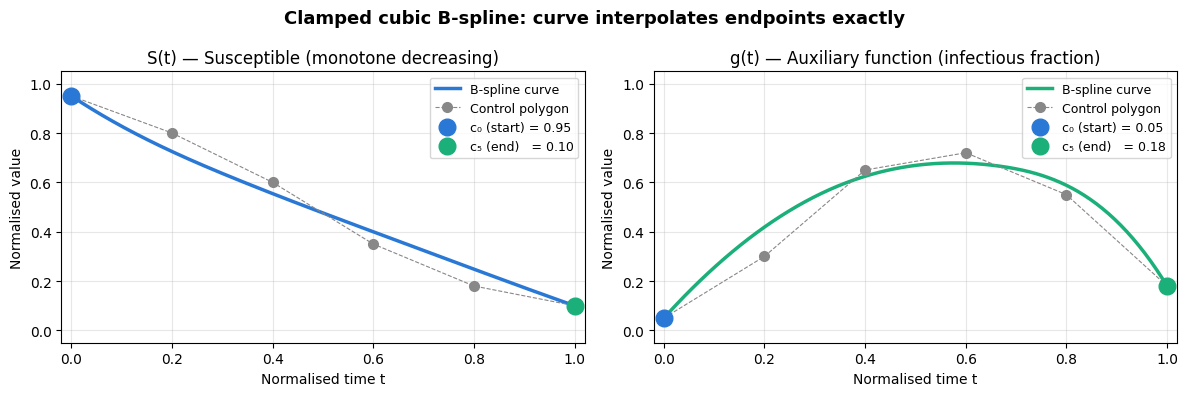

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline

def clamped_bspline(control_points, n_points=250, degree=3):
    """
    Evaluate a clamped cubic B-spline.
    The curve is GUARANTEED to pass through the first
    and last control points exactly.

    Parameters
    ----------
    control_points : array (K, 2) — x,y coordinates
    n_points       : int — resolution of output curve
    degree         : int — polynomial degree (3 = cubic)
    """
    K = len(control_points)

    # Clamped knot vector: repeat boundary knots p+1 times
    # Interior knots evenly spaced
    n_interior = K - degree - 1
    interior   = np.linspace(0, 1, n_interior + 2)[1:-1]
    knots      = np.concatenate([
        np.zeros(degree + 1),   # 0, 0, 0, 0  (repeated p+1 times)
        interior,
        np.ones(degree + 1)     # 1, 1, 1, 1  (repeated p+1 times)
    ])

    print(f"Knot vector: {np.round(knots, 3)}")

    t_vals = np.linspace(0, 1, n_points)

    # Evaluate using de Boor's algorithm (scipy handles this)
    cx = BSpline(knots, control_points[:, 0], degree)(t_vals)
    cy = BSpline(knots, control_points[:, 1], degree)(t_vals)

    return t_vals, cx, cy

# ── Example: S(t) monotone decreasing (susceptible compartment) ─────────
control_points_S = np.array([
    [0.0, 0.95],   # c0 — exact start: curve ALWAYS hits this
    [0.2, 0.80],
    [0.4, 0.60],
    [0.6, 0.35],
    [0.8, 0.18],
    [1.0, 0.10],   # c5 — exact end: curve ALWAYS hits this
])

t, cx, cy = clamped_bspline(control_points_S)

# ── Verify clamping guarantee ───────────────────────────────────────────
print(f"\nClamping verification:")
print(f"  curve(0) = {cy[0]:.8f}")
print(f"  c0.y     = {control_points_S[0,1]:.8f}")
print(f"  Error at start: {abs(cy[0] - control_points_S[0,1]):.2e}")

print(f"  curve(1) = {cy[-1]:.8f}")
print(f"  c5.y     = {control_points_S[-1,1]:.8f}")
print(f"  Error at end:   {abs(cy[-1] - control_points_S[-1,1]):.2e}")

# ── Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (cps, label, color) in zip(axes, [
    (control_points_S, 'S(t) — Susceptible (monotone decreasing)', '#2a78d6'),
    (np.array([[0,0.05],[0.2,0.3],[0.4,0.65],[0.6,0.72],
               [0.8,0.55],[1,0.18]]),
     'g(t) — Auxiliary function (infectious fraction)', '#1baf7a')
]):
    t, cx, cy = clamped_bspline(cps)

    ax.plot(t, cy, color=color, lw=2.5, label='B-spline curve')
    ax.plot(cps[:,0], cps[:,1], 'o--',
            color='#888', ms=7, lw=0.8, label='Control polygon')

    # Highlight the endpoint guarantee
    ax.plot(cps[0,0],  cps[0,1],  'o', ms=12, color='#2a78d6',
            label=f'c₀ (start) = {cps[0,1]:.2f}', zorder=5)
    ax.plot(cps[-1,0], cps[-1,1], 'o', ms=12, color='#1baf7a',
            label=f'c₅ (end)   = {cps[-1,1]:.2f}', zorder=5)

    ax.set_title(label)
    ax.set_xlabel('Normalised time t')
    ax.set_ylabel('Normalised value')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('Clamped cubic B-spline: curve interpolates endpoints exactly',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('clamped_bspline_demo.pdf', dpi=200, bbox_inches='tight')
plt.show()